# Preprocessing

### Loading

In [1]:
import openslide
from PIL import Image
import os
import numpy as np
import torch
import torch.nn as nn
import tifffile
import pandas as pd
from skimage.transform import downscale_local_mean
from skimage import filters, color
from math import ceil
from tqdm import tqdm
from torchvision.transforms import Normalize, Compose
from einops import rearrange
import random
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import timm
import glob
from timm import create_model
from huggingface_hub import login
import rsatoolbox
from rsatoolbox.data import Dataset
from rsatoolbox.rdm import calc_rdm
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr, t
from scipy.cluster.hierarchy import linkage, dendrogram
from timm.layers import SwiGLUPacked
from scipy.spatial.distance import pdist, squareform
from cliffs_delta import cliffs_delta
import itertools
from itertools import combinations
import matplotlib.image as mpimg
from conch.open_clip_custom import create_model_from_pretrained
from transformers import CLIPModel, CLIPProcessor
from sklearn.preprocessing import normalize
import pdb

/homes2/vmishra/miniconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


### Splitting Into 5 Batches of 50 slides/50 patches each for validation

In [13]:
subtypes = ["brca", "coad", "luad", "lusc"]
models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]

base_path = "/lotterlab/users/vmishra/"
output_dir = "/lotterlab/users/vmishra/batched_embeddings"
os.makedirs(output_dir, exist_ok=True)

slides_per_batch = 50
patches_per_slide = 50

for subtype in subtypes:
    for model in models:
        file_path = os.path.join(base_path, f"{subtype}_embeddings_{model}.npy")
        print(f"Processing {file_path}...")

        embeddings = np.load(file_path)
        num_total = 250 * 250
        embedding_dim = embeddings.shape[1]
        assert embeddings.shape[0] == num_total, f"Unexpected shape for {file_path}"

        embeddings = embeddings.reshape(250, 250, embedding_dim)

        for batch_idx in range(5):
            start_slide = batch_idx * slides_per_batch
            end_slide = (batch_idx + 1) * slides_per_batch

            batch = embeddings[start_slide:end_slide, :patches_per_slide, :]
            batch = batch.reshape(-1, embedding_dim)

            batch_filename = f"{subtype}_{model}_batch{batch_idx+1}.npy"
            batch_path = os.path.join(output_dir, batch_filename)
            np.save(batch_path, batch)
            print(f"Saved batch {batch_idx+1} to {batch_path}")

Processing /lotterlab/users/vmishra/brca_embeddings_conch.npy...
Saved batch 1 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch1.npy
Saved batch 2 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch2.npy
Saved batch 3 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch3.npy
Saved batch 4 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch4.npy
Saved batch 5 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch5.npy
Processing /lotterlab/users/vmishra/brca_embeddings_plip.npy...
Saved batch 1 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch1.npy
Saved batch 2 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch2.npy
Saved batch 3 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch3.npy
Saved batch 4 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch4.npy
Saved batch 5 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch5.npy
Processing /lotterlab/users/vmishra/brca_embed

In [14]:
input_dir = "/lotterlab/users/vmishra/batched_embeddings"
rdm_output_dir = "/lotterlab/users/vmishra/rdms"
os.makedirs(rdm_output_dir, exist_ok=True)

subtypes = ["brca", "coad", "luad", "lusc"]
models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]

num_slides = 50
num_patches = 50

for model in models:
    for batch_idx in range(1, 6):
        print(f"Processing RDM for model: {model}, batch: {batch_idx}")

        embeddings_list = []
        labels = []

        for subtype in subtypes:
            file_path = os.path.join(input_dir, f"{subtype}_{model}_batch{batch_idx}.npy")
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}, skipping.")
                continue

            emb = np.load(file_path)
            embeddings_list.append(emb)
            labels.extend([subtype.upper()] * len(emb))

        if len(embeddings_list) < 4:
            print(f"Missing data for model {model}, batch {batch_idx}. Skipping.")
            continue

        embeddings = np.concatenate(embeddings_list, axis=0)

        dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
        rdm = calc_rdm(dataset, method='euclidean')
        rdm_matrix = rdm.get_matrices()[0]

        save_path = os.path.join(rdm_output_dir, f"rdm_matrix_{model}_batch{batch_idx}.npy")
        np.save(save_path, rdm_matrix)
        print(f"Saved RDM to {save_path}")

Processing RDM for model: conch, batch: 1
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch1.npy
Processing RDM for model: conch, batch: 2
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch2.npy
Processing RDM for model: conch, batch: 3
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch3.npy
Processing RDM for model: conch, batch: 4
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch4.npy
Processing RDM for model: conch, batch: 5
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch5.npy
Processing RDM for model: plip, batch: 1
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_batch1.npy
Processing RDM for model: plip, batch: 2
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_batch2.npy
Processing RDM for model: plip, batch: 3
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_batch3.npy
Processing RDM for model: plip, batch: 4
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_ba

# RDMs

conch
plip
prov
quiltnet
resnet
uni
virchow


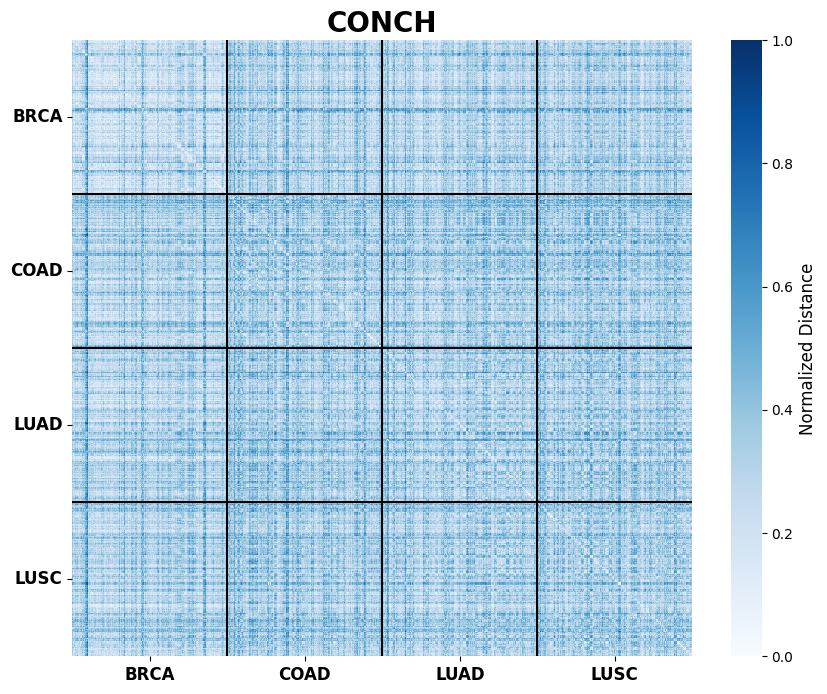

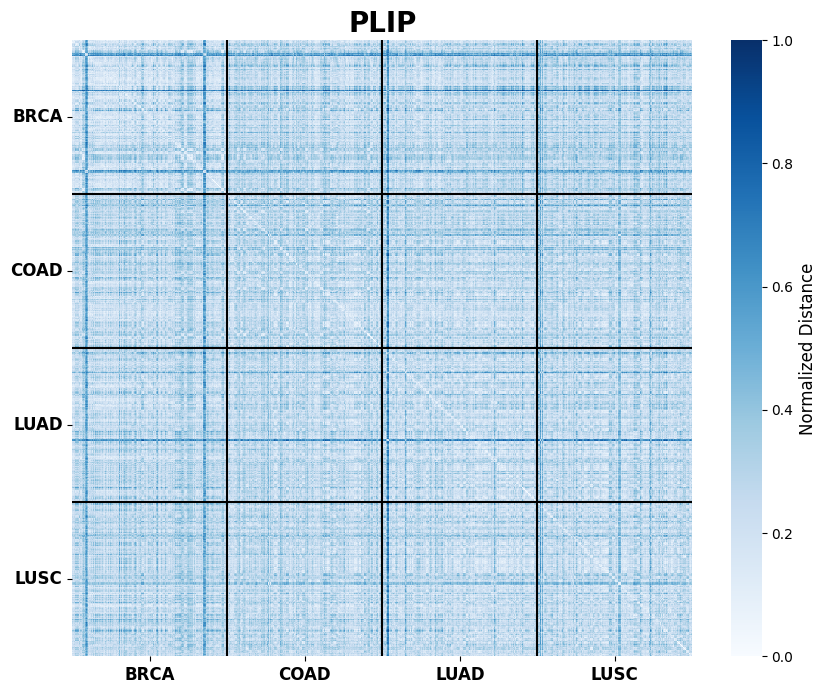

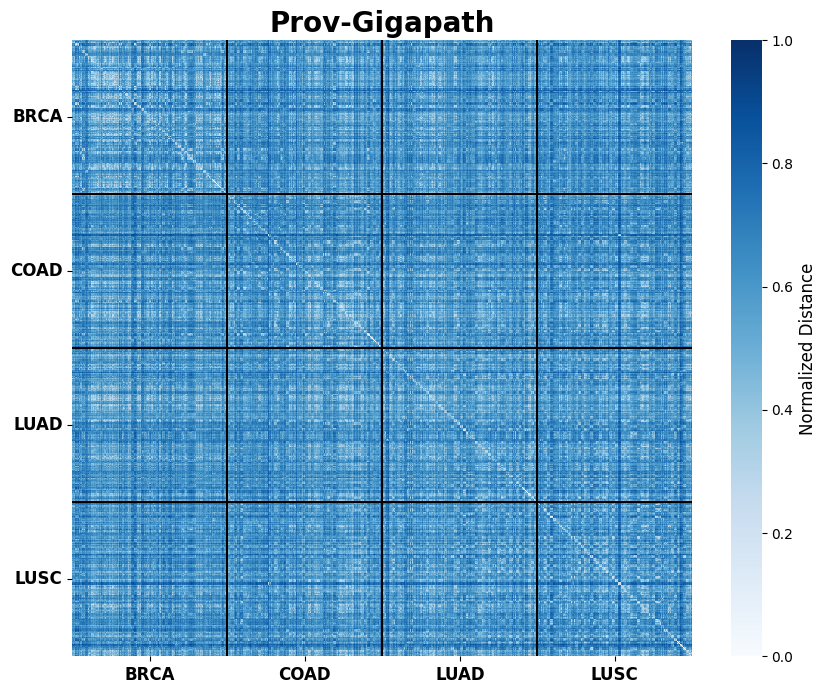

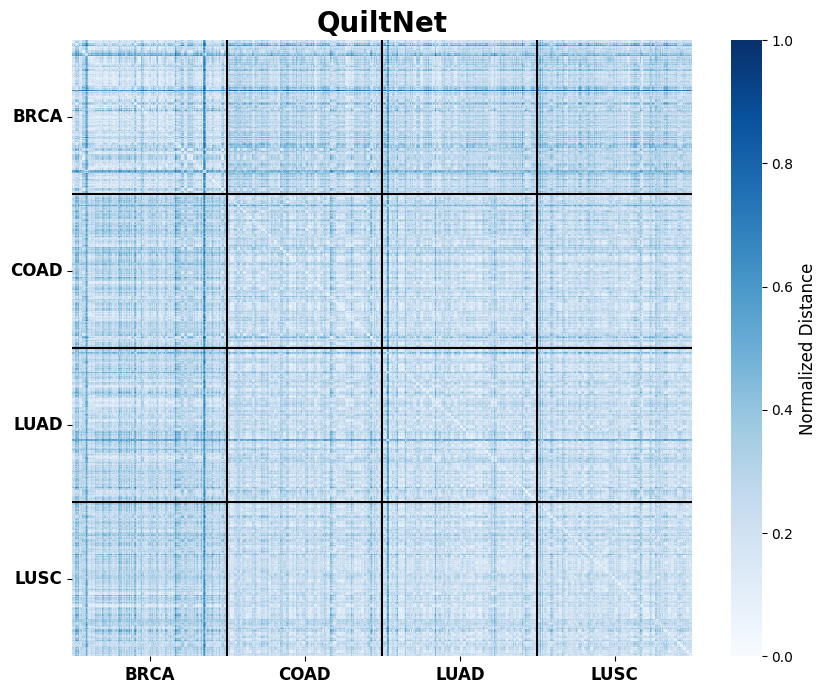

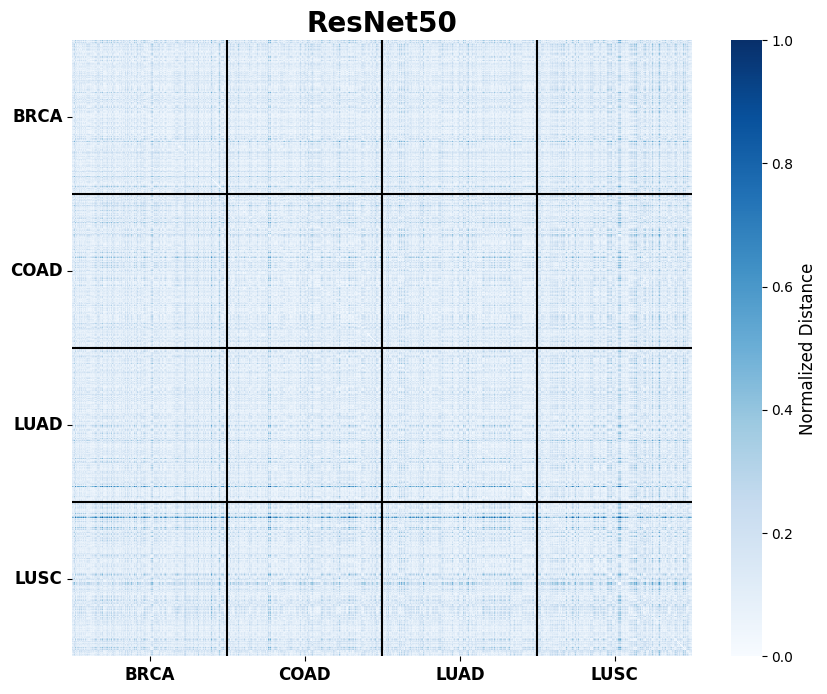

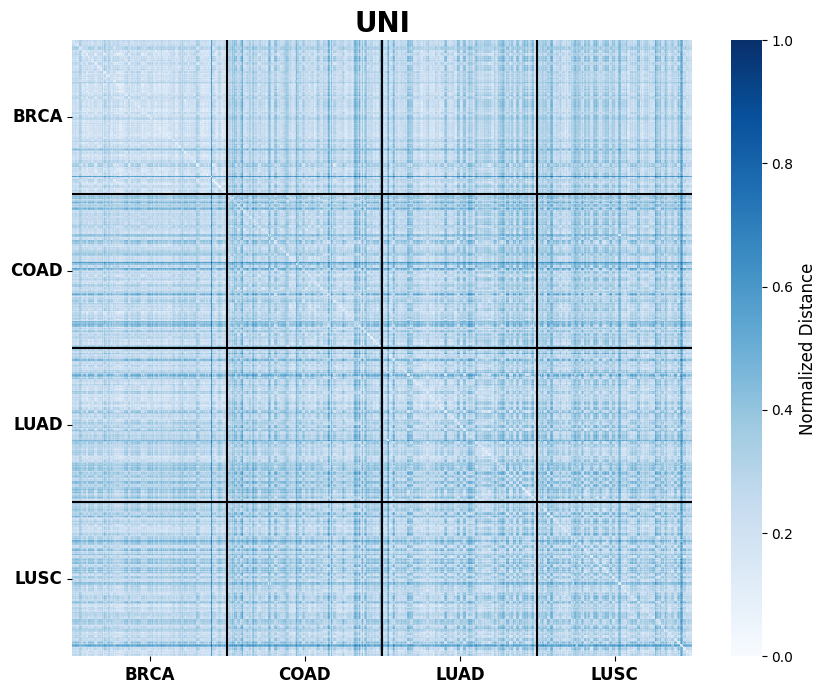

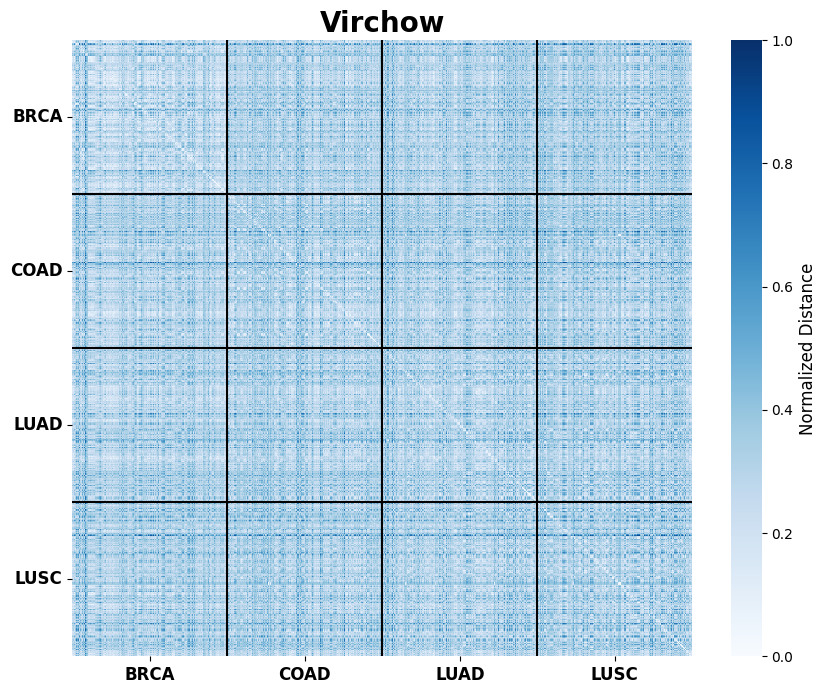

In [2]:
def make_plot(rdm, model_name):
    n = rdm.shape[0] / 4
    divider_positions = [n, 2*n, 3*n]
    diseases = ["BRCA", "COAD", "LUAD", "LUSC"]

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(rdm, cmap='Blues', annot=False, cbar=True)
    ax.collections[0].colorbar.set_label("Normalized Distance", fontsize=12)
    plt.title(model_name, fontweight='bold', fontsize=20)
    plt.xticks([n // 2, n + n // 2, n + n + n // 2, n + n + n + n // 2],
               diseases, rotation=0, ha='center', fontsize=12, fontweight='bold')
    plt.yticks([n // 2, n + n // 2, n + n + n // 2, n + n + n + n // 2],
               diseases, rotation=0, fontsize=12, fontweight='bold')

    # Add divider lines between disease types
    for pos in divider_positions:
        ax.axhline(pos, color='black', linewidth=1.5)
        ax.axvline(pos, color='black', linewidth=1.5)
        
    plt.savefig("rdm_matrixv2-" + model_name + ".png", dpi=300, bbox_inches='tight')

models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]
model_tags = ['CONCH', 'PLIP', 'Prov-Gigapath', 'QuiltNet', 'ResNet50', 'UNI', 'Virchow']

for m, t in zip(models, model_tags):
    print(m)
    rdm_mat = np.load("/lotterlab/users/vmishra/rdms/rdm_matrix_" + m + "_batch1.npy")
    rdm_mat = rdm_mat / rdm_mat.max()
    make_plot(rdm_mat, t)

# Spearman and Cosine Similarity Heatmap

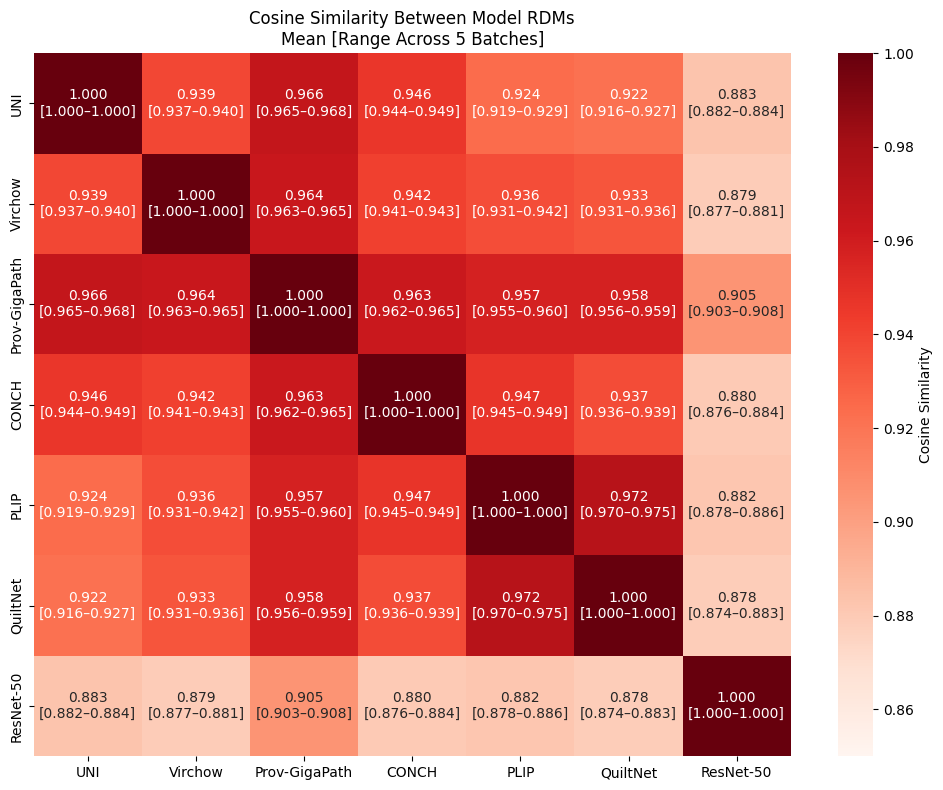

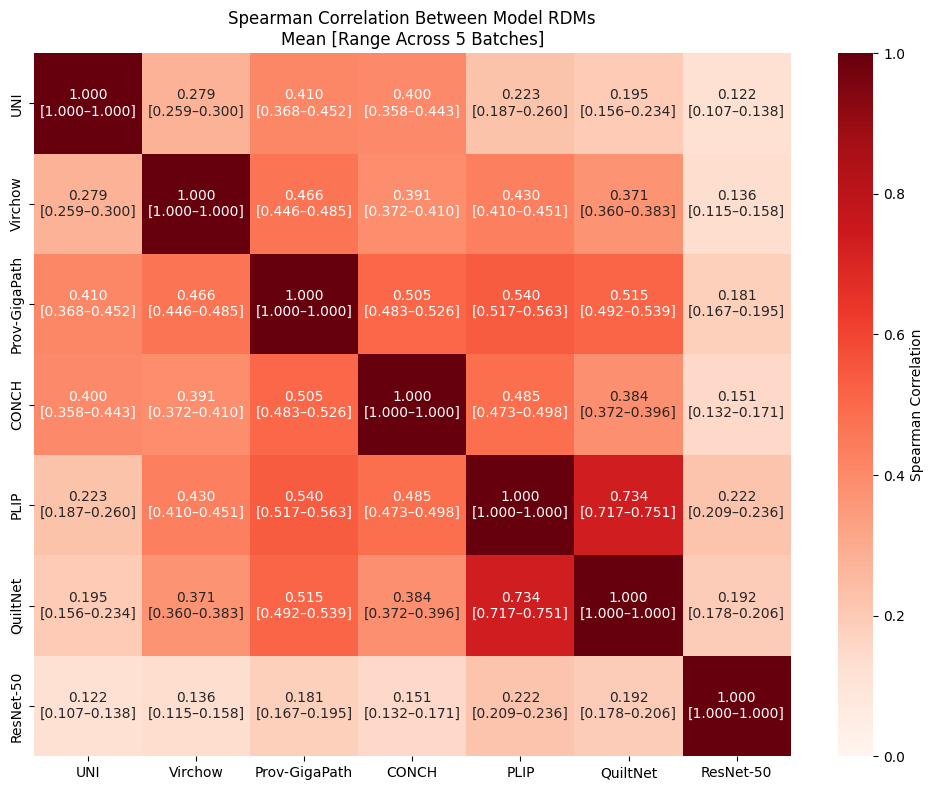

In [20]:
from scipy.stats import spearmanr, t

models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]
n_models = len(models)
rdm_dir = "/lotterlab/users/vmishra/rdms"

cosine_mean = np.zeros((n_models, n_models))
cosine_ci_lower = np.zeros((n_models, n_models))
cosine_ci_upper = np.zeros((n_models, n_models))

spearman_mean = np.zeros((n_models, n_models))
spearman_ci_lower = np.zeros((n_models, n_models))
spearman_ci_upper = np.zeros((n_models, n_models))

def get_confidence_interval(values, confidence=0.95):
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    n = len(values)
    h = t.ppf((1 + confidence) / 2., n - 1) * std / np.sqrt(n)
    return mean, mean - h, mean + h

for i, model_i in enumerate(models):
    for j, model_j in enumerate(models):
        cosine_vals = []
        spearman_vals = []

        for batch in range(1, 6):
            path_i = os.path.join(rdm_dir, f"rdm_matrix_{model_i}_batch{batch}.npy")
            path_j = os.path.join(rdm_dir, f"rdm_matrix_{model_j}_batch{batch}.npy")
            rdm_i = np.load(path_i)
            rdm_j = np.load(path_j)

            tri_i = rdm_i[np.triu_indices_from(rdm_i, k=1)]
            tri_j = rdm_j[np.triu_indices_from(rdm_j, k=1)]

            cos_sim = 1 - cosine(tri_i, tri_j)
            spearman_corr, _ = spearmanr(tri_i, tri_j)

            cosine_vals.append(cos_sim)
            spearman_vals.append(spearman_corr)

        # Cosine
        mean_cos, ci_cos_low, ci_cos_high = get_confidence_interval(cosine_vals)
        cosine_mean[i, j] = mean_cos
        cosine_ci_lower[i, j] = ci_cos_low
        cosine_ci_upper[i, j] = ci_cos_high

        # Spearman
        mean_spear, ci_spear_low, ci_spear_high = get_confidence_interval(spearman_vals)
        spearman_mean[i, j] = mean_spear
        spearman_ci_lower[i, j] = ci_spear_low
        spearman_ci_upper[i, j] = ci_spear_high

# Desired model order and display names
desired_order = ['uni', 'virchow', 'prov', 'conch', 'plip', 'quiltnet', 'resnet']
display_names = ['UNI', 'Virchow', 'Prov-GigaPath', 'CONCH', 'PLIP', 'QuiltNet', 'ResNet-50']
reorder_idx = [models.index(m) for m in desired_order]

# Reorder all matrices
cosine_mean_r = cosine_mean[reorder_idx, :][:, reorder_idx]
cosine_ci_lower_r = cosine_ci_lower[reorder_idx, :][:, reorder_idx]
cosine_ci_upper_r = cosine_ci_upper[reorder_idx, :][:, reorder_idx]

spearman_mean_r = spearman_mean[reorder_idx, :][:, reorder_idx]
spearman_ci_lower_r = spearman_ci_lower[reorder_idx, :][:, reorder_idx]
spearman_ci_upper_r = spearman_ci_upper[reorder_idx, :][:, reorder_idx]

def format_annot(mean_mat, lower_mat, upper_mat):
    n = mean_mat.shape[0]
    annot = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            m = mean_mat[i, j]
            l = lower_mat[i, j]
            u = upper_mat[i, j]
            annot[i, j] = f"{m:.3f}\n[{l:.3f}–{u:.3f}]"
    return annot

cosine_annot = format_annot(cosine_mean_r, cosine_ci_lower_r, cosine_ci_upper_r)
spearman_annot = format_annot(spearman_mean_r, spearman_ci_lower_r, spearman_ci_upper_r)

# Plot cosine similarity
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_mean_r, annot=cosine_annot, fmt="", xticklabels=display_names, yticklabels=display_names,
            cmap="Reds", vmin=0.85, vmax=1, cbar_kws={"label": "Cosine Similarity"})
plt.title("Cosine Similarity Between Model RDMs\nMean [Range Across 5 Batches]")
plt.tight_layout()
plt.savefig("cosineHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot Spearman correlation
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_mean_r, annot=spearman_annot, fmt="", xticklabels=display_names, yticklabels=display_names,
            cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "Spearman Correlation"})
plt.title("Spearman Correlation Between Model RDMs\nMean [Range Across 5 Batches]")
plt.tight_layout()
plt.savefig("spearmanHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Mean Spearman correlation

In [21]:
n_models = len(display_names)

average_spearman_corr = (np.sum(spearman_mean_r, axis=1) - np.diag(spearman_mean_r)) / (n_models - 1)

df_similarity = pd.DataFrame({
    "Model": display_names,
    "Average Spearman Correlation": average_spearman_corr
})

df_similarity

,Model,Average Spearman Correlation
0,UNI,0.271772
1,Virchow,0.345689
2,Prov-GigaPath,0.436080
3,CONCH,0.386029
4,PLIP,0.439151
5,QuiltNet,0.398649
6,ResNet-50,0.167526


# Dendrograms

In [2]:
models = ["UNI", "Virchow", "Prov-GigaPath", "CONCH", "PLIP", "QuiltNet", "ResNet50"]
n_models = len(models)
spearman_mean = np.ones((n_models, n_models))

spearman_mean[0, 1:] = [0.279, 0.41, 0.4, 0.223, 0.195, 0.122]
spearman_mean[1, 2:] = [0.466, 0.391, 0.43, 0.371, 0.136]
spearman_mean[2, 3:] = [0.505, 0.54, 0.515, 0.181]
spearman_mean[3, 4:] = [0.485, 0.384, 0.151]
spearman_mean[4, 5:] = [0.734, 0.222]
spearman_mean[5, 6] = 0.192

for i in range(1, n_models):
    for j in range(i):
        spearman_mean[i, j] = spearman_mean[j, i]

In [3]:
spearman_mean

array([[1.   , 0.279, 0.41 , 0.4  , 0.223, 0.195, 0.122],
       [0.279, 1.   , 0.466, 0.391, 0.43 , 0.371, 0.136],
       [0.41 , 0.466, 1.   , 0.505, 0.54 , 0.515, 0.181],
       [0.4  , 0.391, 0.505, 1.   , 0.485, 0.384, 0.151],
       [0.223, 0.43 , 0.54 , 0.485, 1.   , 0.734, 0.222],
       [0.195, 0.371, 0.515, 0.384, 0.734, 1.   , 0.192],
       [0.122, 0.136, 0.181, 0.151, 0.222, 0.192, 1.   ]])

In [4]:
spearman_distances = 1 - spearman_mean

# Convert to condensed form
spearman_condensed = squareform(spearman_distances, checks=False)

# Hierarchical Clustering (Ward's method)
linkage_spearman = linkage(spearman_condensed, method="ward")


In [5]:
thresholds = [0.1, 0.33, 0.55, 0.62, 0.70, 0.81, 1.00]

# Get Seaborn color palette with one more color than thresholds
colors = sns.color_palette("deep", len(thresholds) + 1)
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'gray']

# Custom link color function based on thresholds
def link_color_func(link_id):
    print(link_id)
    #print(link_id)
#     if link_id < linkage_spearman.shape[0]:
#         print(link_id)
    row = link_id - linkage_spearman.shape[0] - 1
    dist = linkage_spearman[row, 2]  # height of the node
    for i, t in enumerate(thresholds):
        if dist < t:
            return colors[i]
    return colors[-1]
#     else:
#         return 'black'

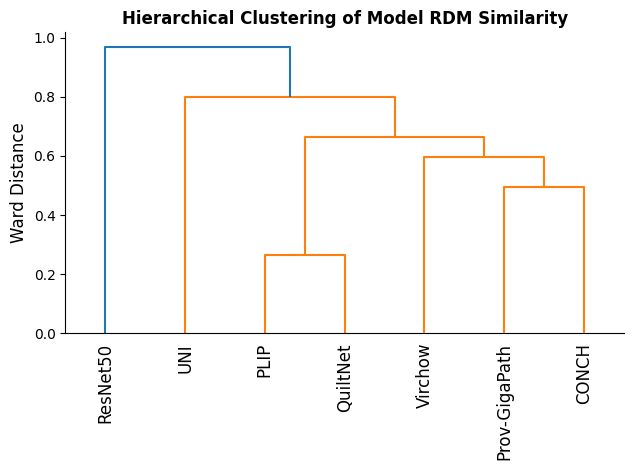

In [6]:
fig, ax = plt.subplots()

#plt.figure(figsize=(10, 5))
ct = [1, ]
dendrogram(linkage_spearman, labels=models, leaf_rotation=90, leaf_font_size=12, color_threshold=0.82) #, link_color_func=link_color_func)
plt.title("Hierarchical Clustering of Model RDM Similarity", fontweight='bold')
#plt.xlabel("Models")
plt.ylabel("Distance")
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Ward Distance', fontsize=12) #, fontweight='bold')

plt.savefig('ClusteringSpearman_v2.pdf')

In [7]:
linkage_spearman.shape

(6, 4)

In [8]:
linkage_spearman

array([[ 4.        ,  5.        ,  0.266     ,  2.        ],
       [ 2.        ,  3.        ,  0.495     ,  2.        ],
       [ 1.        ,  8.        ,  0.59639165,  3.        ],
       [ 7.        ,  9.        ,  0.66489247,  5.        ],
       [ 0.        , 10.        ,  0.80060852,  6.        ],
       [ 6.        , 11.        ,  0.96951092,  7.        ]])

In [9]:
colors[0]

'blue'

In [10]:
colors

['blue', 'orange', 'green', 'red', 'purple', 'brown', 'gray']

In [11]:
models = ["UNI", "Virchow", "Prov-GigaPath", "CONCH", "PLIP", "QuiltNet", "ResNet50"]
# just copied from plot since taking so long
n_models = len(models)
cosine_mean = np.ones((n_models, n_models))

cosine_mean[0, 1:] = [0.939, 0.966, 0.946, 0.924, 0.922, 0.883]
cosine_mean[1, 2:] = [0.964, 0.942, 0.936, 0.933, 0.879]
cosine_mean[2, 3:] = [0.963, 0.957, 0.958, 0.905]
cosine_mean[3, 4:] = [0.947, 0.937, 0.88]
cosine_mean[4, 5:] = [0.972, 0.882]
cosine_mean[5, 6] = 0.878

for i in range(1, n_models):
    for j in range(i):
        cosine_mean[i, j] = cosine_mean[j, i]

In [12]:
cosine_mean

array([[1.   , 0.939, 0.966, 0.946, 0.924, 0.922, 0.883],
       [0.939, 1.   , 0.964, 0.942, 0.936, 0.933, 0.879],
       [0.966, 0.964, 1.   , 0.963, 0.957, 0.958, 0.905],
       [0.946, 0.942, 0.963, 1.   , 0.947, 0.937, 0.88 ],
       [0.924, 0.936, 0.957, 0.947, 1.   , 0.972, 0.882],
       [0.922, 0.933, 0.958, 0.937, 0.972, 1.   , 0.878],
       [0.883, 0.879, 0.905, 0.88 , 0.882, 0.878, 1.   ]])

In [13]:
cosine_distances = 1 - cosine_mean

# Convert to condensed form
cosine_condensed = squareform(cosine_distances, checks=False)

# Hierarchical Clustering (Ward's method)
linkage_cosine = linkage(cosine_condensed, method="ward")

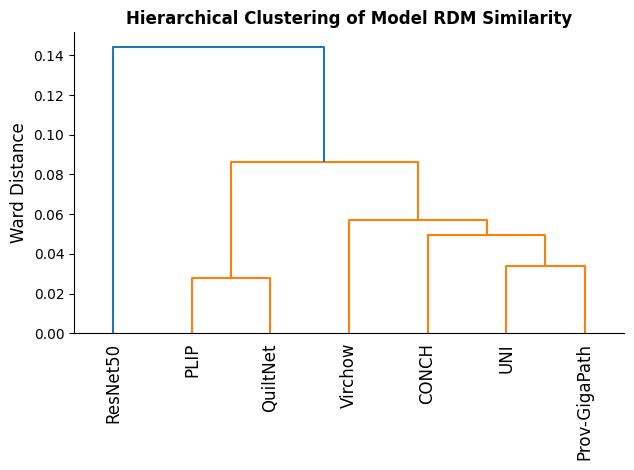

In [14]:
fig, ax = plt.subplots()

#plt.figure(figsize=(10, 5))
ct = [1, ]
dendrogram(linkage_cosine, labels=models, leaf_rotation=90, leaf_font_size=12, color_threshold=0.14) #, link_color_func=link_color_func)
plt.title("Hierarchical Clustering of Model RDM Similarity", fontweight='bold')
#plt.xlabel("Models")
plt.ylabel("Distance")
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Ward Distance', fontsize=12) #, fontweight='bold')

plt.savefig('ClusteringCosine_v2.pdf')

# Slide Specificity

In [18]:
from bisect import bisect_right, bisect_left
from scipy.spatial.distance import pdist
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

models = ['conch', 'plip', 'virchow', 'uni', 'quiltnet', 'prov', 'resnet']
display_names = ['CONCH', 'PLIP', 'Virchow', 'UNI', 'QuiltNet', 'Prov-GigaPath', 'ResNet-50']
subtypes = ['brca', 'coad', 'luad', 'lusc']

num_slides = 50
patches_per_slide = 50
n_batches = 5
rdm_root = "/lotterlab/users/vmishra/batched_embeddings"

def calculate_distances(embeddings, num_slides=50, patches_per_slide=50):
    intra_distances = []
    inter_distances = []

    for slide_idx in range(num_slides):
        slide_indices = np.arange(slide_idx * patches_per_slide, (slide_idx + 1) * patches_per_slide)
        other_indices = np.setdiff1d(np.arange(embeddings.shape[0]), slide_indices)

        slide_distances = pdist(embeddings[slide_indices], metric='euclidean')
        intra_distances.extend(slide_distances)

        for other_idx in other_indices:
            inter_distances.extend(np.linalg.norm(embeddings[slide_indices] - embeddings[other_idx], axis=1))

    return np.array(intra_distances), np.array(inter_distances)

def efficient_cliffs_delta(a, b):
    a = np.sort(a)
    b = np.sort(b)
    m, n = len(a), len(b)
    more = sum(bisect_right(b, x) for x in a)
    less = sum(n - bisect_left(b, x) for x in a)
    delta = (more - less) / (m * n)
    return delta

results = []

for model in tqdm(models, desc="Processing models"):
    delta_vals = []

    for batch in range(1, n_batches + 1):
        embeddings_list = []
        for subtype in subtypes:
            file_path = os.path.join(rdm_root, f"{subtype}_{model}_batch{batch}.npy")
            emb = np.load(file_path)
            embeddings_list.append(emb)

        all_embeddings = np.vstack(embeddings_list)
        intra, inter = calculate_distances(all_embeddings, num_slides=num_slides * 4, patches_per_slide=patches_per_slide)

        delta_vals.append(efficient_cliffs_delta(intra, inter))

    delta_vals = np.array(delta_vals)

    results.append({
        "model": model,
        "display_name": display_names[models.index(model)],
        "cliffs_delta_mean": delta_vals.mean(),
        "cliffs_delta_min": delta_vals.min(),
        "cliffs_delta_max": delta_vals.max()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="cliffs_delta_mean", ascending=False).reset_index(drop=True)
results_df.to_csv("slide_specificity.csv", index=False)
print(results_df)

Processing models: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [55:53<00:00, 479.13s/it]


      model   display_name  cliffs_delta_mean  cliffs_delta_min  \
0    resnet      ResNet-50          -0.431175         -0.442581   
1     conch          CONCH          -0.597020         -0.611729   
2   virchow        Virchow          -0.612947         -0.625277   
3      plip           PLIP          -0.708291         -0.726396   
4  quiltnet       QuiltNet          -0.731389         -0.744131   
5      prov  Prov-GigaPath          -0.751410         -0.759641   
6       uni            UNI          -0.753429         -0.766655   

   cliffs_delta_max  
0         -0.416674  
1         -0.575500  
2         -0.593681  
3         -0.695208  
4         -0.718123  
5         -0.738231  
6         -0.727956  


# Disease Specificity

In [19]:
from bisect import bisect_right, bisect_left
from scipy.spatial.distance import pdist
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

models = ['conch', 'plip', 'virchow', 'uni', 'quiltnet', 'prov', 'resnet']
display_names = ['CONCH', 'PLIP', 'Virchow', 'UNI', 'QuiltNet', 'Prov-GigaPath', 'ResNet-50']
subtypes = ['brca', 'coad', 'luad', 'lusc']
num_slides = 50
patches_per_slide = 50
n_batches = 5
embedding_dir = "/lotterlab/users/vmishra/batched_embeddings"

def efficient_cliffs_delta(a, b):
    a = np.sort(a)
    b = np.sort(b)
    m, n = len(a), len(b)
    more = sum(bisect_right(b, x) for x in a)
    less = sum(n - bisect_left(b, x) for x in a)
    delta = (more - less) / (m * n)
    return delta

results = []

for model in tqdm(models, desc="Processing models"):
    delta_vals = []

    for batch in range(1, n_batches + 1):
        disease_embeddings = {}
        for subtype in subtypes:
            file_path = os.path.join(embedding_dir, f"{subtype}_{model}_batch{batch}.npy")
            disease_embeddings[subtype] = np.load(file_path)

        intra_distances = []
        for subtype in subtypes:
            emb = disease_embeddings[subtype]
            dists = pdist(emb, metric='euclidean')
            intra_distances.extend(dists)

        inter_distances = []
        for i in range(len(subtypes)):
            for j in range(i + 1, len(subtypes)):
                emb1 = disease_embeddings[subtypes[i]]
                emb2 = disease_embeddings[subtypes[j]]
                diffs = np.linalg.norm(emb1[:, None, :] - emb2[None, :, :], axis=2).flatten()
                inter_distances.extend(diffs)

        intra = np.array(intra_distances)
        inter = np.array(inter_distances)

        delta_vals.append(efficient_cliffs_delta(intra, inter))

    delta_vals = np.array(delta_vals)

    results.append({
        "model": model,
        "display_name": display_names[models.index(model)],
        "cliffs_delta_mean": delta_vals.mean(),
        "cliffs_delta_min": delta_vals.min(),
        "cliffs_delta_max": delta_vals.max()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="cliffs_delta_mean", ascending=False).reset_index(drop=True)
results_df.to_csv("disease_specificity.csv", index=False)
print(results_df)

Processing models: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [1:42:05<00:00, 875.07s/it]

      model   display_name  cliffs_delta_mean  cliffs_delta_min  \
0    resnet      ResNet-50          -0.036314         -0.042607   
1   virchow        Virchow          -0.092972         -0.100155   
2      prov  Prov-GigaPath          -0.097294         -0.112558   
3     conch          CONCH          -0.101167         -0.113526   
4      plip           PLIP          -0.106050         -0.122542   
5       uni            UNI          -0.114105         -0.129938   
6  quiltnet       QuiltNet          -0.173861         -0.188402   

   cliffs_delta_max  
0         -0.032118  
1         -0.079561  
2         -0.084828  
3         -0.089660  
4         -0.090825  
5         -0.091945  
6         -0.158816  


# Spectral Analysis


Processing UNI...

Processing Virchow...

Processing Prov-GigaPath...

Processing CONCH...

Processing PLIP...

Processing QuiltNet...

Processing ResNet-50...
UNI
Virchow
Prov-GigaPath
CONCH
PLIP
QuiltNet
ResNet-50
UNI (250000, 1536)
Virchow (250000, 2560)
Prov-GigaPath (250000, 1536)
CONCH (250000, 512)
PLIP (250000, 512)
QuiltNet (250000, 512)
ResNet-50 (250000, 1000)


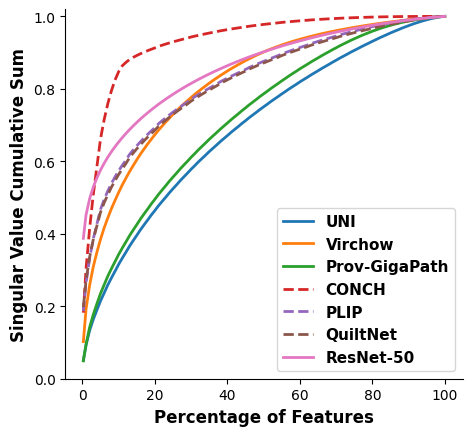

In [17]:
models = ["UNI", "Virchow", "Prov-GigaPath", "CONCH", "PLIP", "QuiltNet", "ResNet-50"]
model_file_keys = {
    "UNI": "uni",
    "Virchow": "virchow",
    "Prov-GigaPath": "prov",
    "CONCH": "conch",
    "PLIP": "plip",
    "QuiltNet": "quiltnet",
    "ResNet-50": "resnet"
}

vl_models = ["PLIP", "QuiltNet", "CONCH"]
subtypes = ["brca", "coad", "luad", "lusc"]

embedding_dir = "/lotterlab/users/vmishra"

embeddings = {}

for model_name in models:
    model_key = model_file_keys[model_name]
    embeddings_list = []

    print(f"\nProcessing {model_name}...")
    for subtype in subtypes:
        file_path = os.path.join(embedding_dir, f"{subtype}_embeddings_{model_key}.npy")
        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        emb = np.load(file_path)
        embeddings_list.append(emb)

    if len(embeddings_list) < 4:
        print(f"Skipping {model_name} due to missing data.")
        continue

    embeddings[model_name] = np.concatenate(embeddings_list, axis=0)

#     # Normalize and center
#     embeddings = normalize(embeddings, axis=1)
#     embeddings -= embeddings.mean(axis=0)


spectra = {}
for model_name in models:
    print(model_name)
    U, S, Vt = np.linalg.svd(embeddings[model_name], full_matrices=False)
    normalized_spectrum = S / S.sum()
    spectra[model_name] = normalized_spectrum

for model_name in models:
    print(model_name, embeddings[model_name].shape)

normalized_spectrum.sum(axis=-1)

p_test = [0.25] + list(range(1, 101))
s_sums = np.zeros((len(models), len(p_test)))
for i, m in enumerate(models):
    n_feat = embeddings[m].shape[-1]
    for j, p in enumerate(p_test):
        cut_off = int(np.round(n_feat * p/100))
        s_sums[i, j] = spectra[m][:(cut_off+1)].sum()

fig, ax = plt.subplots()

for i, m in enumerate(models):
    line_style = '--' if m in vl_models else '-'
    plt.plot(p_test, s_sums[i], label=m, linewidth=2, linestyle=line_style)

plt.legend(prop={'weight':'bold', 'size': 11})
ax.set_ylim([0, 1.02])
ax.set_aspect(100, adjustable='box')
plt.xlabel('Percentage of Features', fontsize=12, fontweight='bold')
plt.ylabel('Singular Value Cumulative Sum', fontsize=12, fontweight='bold')
#plt.title('SVD Spectral Analysis')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('spectral_analysis.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)